#  Endterm Activity <hr style="border:2.5px solid #126782"></hr>

<b>Axel Nazir M. Belnas</b>
<br>3rd year

In [1]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [2]:
df = pd.read_csv(r'dataset\dataset.csv', delimiter=',')
df[["Hydroelectric", "Nuclear"]].head()

,Hydroelectric,Nuclear
0,1718.366667,1354.733333
1,1684.800000,1210.000000
2,1734.766667,1274.600000
3,1793.966667,1237.166667
4,1851.100000,1250.033333


In [3]:
df[["Hydroelectric", "Nuclear"]].describe()

,Hydroelectric,Nuclear
count,50.000000,50.000000
mean,1798.315333,1282.553333
std,149.247573,46.755288
min,1388.566667,1187.800000
25%,1697.258333,1258.041667
50%,1791.450000,1290.916667
75%,1893.341667,1309.208333
max,2196.533333,1375.200000


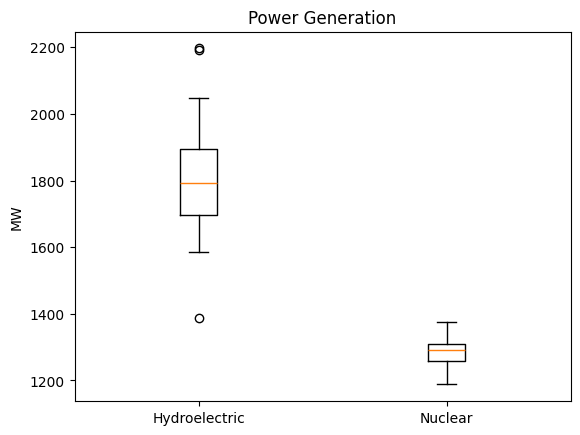

In [7]:
for col in ["Hydroelectric", "Nuclear"]:
    z = stats.zscore(df[col])
    df = df[(z > -3) & (z < 3)]

plt.boxplot(df[['Hydroelectric', 'Nuclear']],tick_labels=['Hydroelectric', 'Nuclear'])
plt.title("Power Generation")
plt.ylabel('MW')
plt.show()

In [6]:
alpha = 0.05

for col in ["Hydroelectric", "Nuclear"]:
    w_stat, p_value = stats.shapiro(df[col])
    print(f"{col}:")
    print(f"  W-statistic: {w_stat:.4f}")
    print(f"  P-value:     {p_value:.4f}")
    if p_value < alpha:
        print("  Result: Non-normal data")
    else:
        print("  Result: Normal data")
    print()

Hydroelectric:
  W-statistic: 0.9674
  P-value:     0.1814
  Result: Normal data

Nuclear:
  W-statistic: 0.9716
  P-value:     0.2682
  Result: Normal data



In [8]:
var_comp1 = df['Hydroelectric'].var(ddof=1)
var_comp2 = df['Nuclear'].var(ddof=1)

# F-statistic
if var_comp1 > var_comp2:
    f_stat = var_comp1/var_comp2
else:
    f_stat = var_comp2/var_comp1

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_comp1 = df['Hydroelectric'].count()-1
dof_comp2 = df['Nuclear'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_comp1, dof_comp2)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 10.1895
p_value = 0.0000
unequal variances


In [48]:
t_stat, p_value = stats.ttest_ind(df['Hydroelectric'],df['Nuclear'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("There is difference between Hydroelectric and Nuclear.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between Hydroelectric and Nuclear.")

t_stat = 23.3184
p_value = 0.0000
There is difference between Hydroelectric and Nuclear.


In [51]:
comp1_mean = df['Hydroelectric'].mean()
comp2_mean = df['Nuclear'].mean()
comp1_std = df['Hydroelectric'].std(ddof=1)

d = abs((comp1_mean - comp2_mean)/comp1_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['Nuclear'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 3.4557
Power of the test: 100.00%
